<a href="https://colab.research.google.com/github/nguyenphamduyluan28-boop/THDeepLearning/blob/main/LAB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

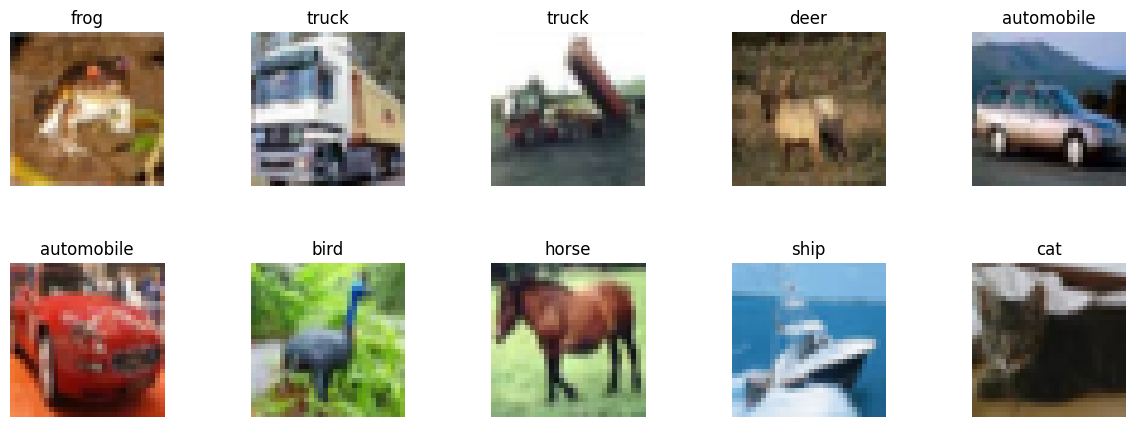

In [36]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Tải lại bộ dữ liệu CIFAR-10 để đảm bảo X_train, y_train là dữ liệu ảnh
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Chuẩn hóa giá trị điểm ảnh về đoạn [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Danh sách các nhãn tương ứng (đảm bảo nó có sẵn)
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Khởi tạo khung chứa lưới đồ thị gồm 2 dòng và 5 cột (tổng cộng 10 ảnh)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))

# Làm phẳng mảng các trục tọa độ (axes) từ 2D thành 1D để dễ dàng lặp qua
ax = axes.ravel()

# Lặp qua 10 phần tử đầu tiên của tập dữ liệu
for i in range(10):
    # Hiển thị trực tiếp ảnh 32x32x3 của CIFAR-10
    ax[i].imshow(X_train[i])

    # Đặt tiêu đề dựa trên nhãn số từ class_names
    # y_train[i] có thể là một mảng 1 phần tử (e.g., [6]), nên lấy phần tử đầu tiên
    ax[i].set_title(class_names[y_train[i][0]])

    ax[i].axis('off') # Ẩn trục tọa độ để ảnh đẹp hơn

# Điều chỉnh khoảng cách theo chiều dọc giữa các dòng ảnh để không bị đè chữ
plt.subplots_adjust(hspace=0.5)

# Hiển thị toàn bộ lưới ảnh lên màn hình
plt.show()

In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# 1. Danh sách nhãn CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 2. Kích hoạt hộp thoại upload file của Colab
print("Hãy chọn một file ảnh từ máy tính của bạn:")
uploaded = files.upload()

# 3. Kiểm tra xem người dùng có upload file nào không
if uploaded:
    # Lấy tên file đầu tiên được upload
    file_name = list(uploaded.keys())[0]
    image_bytes = uploaded[file_name]

    # 4. Mở và tiền xử lý ảnh
    img = Image.open(io.BytesIO(image_bytes))
    img_resized = img.convert('RGB').resize((32, 32)) # Đưa về đúng kích thước 32x32

    img_array = np.array(img_resized) / 255.0         # Chuẩn hóa [0, 1]
    img_input = np.expand_dims(img_array, axis=0)     # Thêm chiều batch (1, 32, 32, 3)

    # 5. Mô hình dự đoán
    prediction = model.predict(img_input, verbose=0)
    predicted_class_idx = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class_idx] * 100

    # 6. Hiển thị kết quả
    plt.figure(figsize=(4, 4))
    plt.imshow(img_resized)
    plt.title(f"Dự đoán: {class_names[predicted_class_idx]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
else:
    print("Bạn chưa chọn file nào.")

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo mô hình
fashion_model = Sequential()

# Lớp ẩn (Sửa relu -> 'relu')
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Lớp đầu ra
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,202 (32.04 KB)

 Trainable params: 8,202 (32.04 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Khởi tạo lại mô hình từ đầu để xóa cấu hình cũ
fashion_model = Sequential()

# Định nghĩa chính xác input_dim là 3072 (độ dài sau khi flatten ảnh CIFAR-10)
fashion_model.add(Dense(input_dim=3072, units=256, kernel_initializer='uniform', activation='relu'))

# Lớp đầu ra 10 nút
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# In bảng summary để chắc chắn Layer đầu tiên nhận "Output Shape = (None, 256)" và Connected từ 3072 biến
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

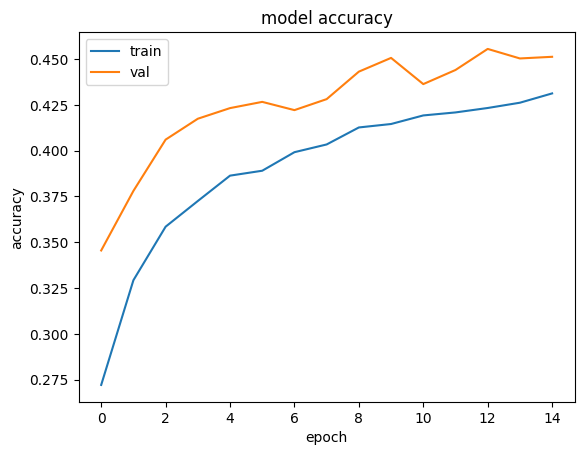

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [39]:
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
print(np.argmax(fashion_model.predict(X_test_flattened)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test_flattened)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
0 [3]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
0 [0]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Tải bộ dữ liệu CIFAR-10 có sẵn trong TensorFlow
print("Đang tải dữ liệu CIFAR-10...")
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Tiền xử lý dữ liệu
# Chuẩn hóa giá trị điểm ảnh về đoạn [0, 1] để mô hình hội tụ nhanh hơn
X_train, X_test = X_train / 255.0, X_test / 255.0

# Danh sách các nhãn tương ứng theo yêu cầu bài toán
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 3. Xây dựng cấu trúc mạng ANN (Multi-Layer Perceptron)
model = models.Sequential([
    # Lớp làm phẳng ảnh từ 3D (32x32x3) thành 1D (3072)
    layers.Flatten(input_shape=(32, 32, 3)),

    # Lớp ẩn thứ nhất (Hidden Layer 1)
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2), # Hạn chế Overfitting

    # Lớp ẩn thứ hai (Hidden Layer 2)
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    # Lớp ẩn thứ ba (Hidden Layer 3)
    layers.Dense(128, activation='relu'),

    # Lớp đầu ra (Output Layer) với 10 nút tương ứng với 10 nhãn phân lớp
    layers.Dense(10, activation='softmax')
])

# Hiển thị cấu trúc mạng thông qua bảng tóm tắt
model.summary()

# 4. Biên dịch mô hình (Compile)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình (Training)
# Bạn có thể tăng epochs lên (ví dụ: 20-30) để đạt độ chính xác cao hơn
EPOCHS = 15
BATCH_SIZE = 64

print(f"\nBắt đầu huấn luyện mô hình trong {EPOCHS} epochs...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test)
)

# 6. Đánh giá mô hình trên tập kiểm tra (Test set)
print("\n--- Đánh giá mô hình ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Độ chính xác trên tập kiểm tra (Test Accuracy): {test_acc * 100:.2f}%")

# 7. Trực quan hóa kết quả huấn luyện (Đồ thị Loss và Accuracy)
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Độ chính xác qua các Epoch')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Hàm mất mát qua các Epoch')

plt.show()

# 8. Dự đoán thử nghiệm trên một vài hình ảnh từ tập test
predictions = model.predict(X_test)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i])

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i][0]

    # Định dạng màu chữ: Xanh nếu đúng, Đỏ nếu sai
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(
        f"Predict: {class_names[predicted_label]}\nTrue: {class_names[true_label]}",
        color=color
    )
plt.tight_layout()
plt.show()

Đang tải dữ liệu CIFAR-10...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện mô hình trong 15 epochs...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.2734 - loss: 1.9742 - val_accuracy: 0.3300 - val_loss: 1.8288
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.3361 - loss: 1.8226 - val_accuracy: 0.3581 - val_loss: 1.7716
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.3625 - loss: 1.7600 - val_accuracy: 0.4017 - val_loss: 1.6751
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.3770 - loss: 1.7185 - val_accuracy: 0.4202 - val_loss: 1.6304
Epoch 5/15
573/782 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3857 - loss: 1.6927

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential

# =====================================================================
# BƯỚC 1: TẢI VÀ TIỀN XỬ LÝ BỘ DỮ LIỆU MNIST (CHỮ SỐ VIẾT TAY)
# =====================================================================
print("--- 1. Đang tải và tiền xử lý dữ liệu MNIST ---")
# Tải bộ dữ liệu có sẵn từ thư viện Keras
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Chuẩn hóa giá trị pixel từ [0, 255] về đoạn [0.0, 1.0] để mạng học tốt hơn
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Kích thước tập huấn luyện (Train set): {X_train.shape}")
print(f"Kích thước tập kiểm tra (Test set): {X_test.shape}\n")


# =====================================================================
# BƯỚC 2: XÂY DỰNG MẠNG NƠ-RON NHÂN TẠO (ANN ARCHITECTURE)
# =====================================================================
print("--- 2. Đang khởi tạo cấu trúc mạng ANN ---")
model = Sequential(
    [
        # Tầng Flatten: Dẹt ảnh 2D (28, 28) thành vector phẳng 1D (784 phần tử)
        Flatten(input_shape=(28, 28)),
        # Tầng ẩn 1: 128 nơ-ron, hàm kích hoạt ReLU
        Dense(128, activation="relu"),
        # Tầng ẩn 2: 64 nơ-ron, hàm kích hoạt ReLU
        Dense(64, activation="relu"),
        # Tầng đầu ra: 10 nơ-ron tương ứng với 10 lớp (Từ Số 0 -> Số 9)
        # Sử dụng hàm Softmax để trả về phân phối xác suất
        Dense(10, activation="softmax"),
    ]
)

# Biên dịch mô hình (Compile)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Hiển thị cấu trúc chi tiết của mạng
model.summary()
print("\n")


# =====================================================================
# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH (TRAINING)
# =====================================================================
print("--- 3. Bắt đầu quá trình huấn luyện (Training) ---")
# Huấn luyện trong 5 kỷ nguyên (epochs), truyền dữ liệu validation để đánh giá
model_fit = model.fit(
    X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test)
)
print("\n")


# =====================================================================
# BƯỚC 4: VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (ACCURACY GRAPH)
# =====================================================================
print("--- 4. Đang hiển thị đồ thị độ chính xác ---")
plt.figure(figsize=(8, 5))
plt.plot(model_fit.history["accuracy"])
plt.plot(model_fit.history["val_accuracy"])
plt.title("MÔ HÌNH ĐỘ CHÍNH XÁC (MODEL ACCURACY)")
plt.ylabel("Độ chính xác (Accuracy)")
plt.xlabel("Kỷ nguyên (Epoch)")
plt.legend(["Train (Tập huấn luyện)", "Val (Tập kiểm thử)"], loc="upper left")
plt.grid(True)
plt.show()
print("\n")


# =====================================================================
# BƯỚC 5: ĐÁNH GIÁ TRÊN CÁC PHẦN TỬ CỦA TẬP TEST GỐC
# =====================================================================
print("--- 5. Dự đoán thử nghiệm trên tập dữ liệu Test có sẵn ---")
# Lấy dự đoán của toàn bộ tập kiểm thử
predictions = model.predict(X_test)

# Xem thử mẫu số 0 và mẫu số 10
idx1, idx2 = 0, 10
pred_label_1 = np.argmax(predictions[idx1])
pred_label_2 = np.argmax(predictions[idx2])

print(
    f"Mẫu dữ liệu Test vị trí [{idx1}] -> Máy đoán: Số {pred_label_1} | Thực tế: Số {y_test[idx1]}"
)
print(
    f"Mẫu dữ liệu Test vị trí [{idx2}] -> Máy đoán: Số {pred_label_2} | Thực tế: Số {y_test[idx2]}\n"
)


# =====================================================================
# BƯỚC 6: KIỂM TRA BẰNG TẤM ẢNH BÊN NGOÀI (NẾU CÓ)
# =====================================================================
print("--- 6. Kiểm tra dự đoán với một file ảnh bên ngoài ---")
IMAGE_PATH = "/content/dress.jpg"  # Bạn có thể đổi tên thành file ảnh số của bạn (VD: số_5.jpg)

if os.path.exists(IMAGE_PATH):
    print(f"Tìm thấy file ảnh tại: {IMAGE_PATH}. Tiến hành xử lý...")

    # 1. Tải ảnh dưới dạng ảnh xám (grayscale) và ép kích thước về (28, 28)
    img = tf.keras.preprocessing.image.load_img(
        IMAGE_PATH, color_mode="grayscale", target_size=(28, 28)
    )

    # 2. Chuyển ảnh thành mảng mumpuy và chuẩn hóa chia 255.0
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0

    # 3. Đổi chiều ảnh về cấu trúc (1, 28, 28) để khớp với tầng Flatten đầu vào của mạng
    img_input = img_array.reshape(1, 28, 28)

    # 4. Dự đoán
    img_predict = model.predict(img_input)
    score = np.argmax(img_predict)

    print(f"\n==> KẾT QUẢ: Máy tính dự đoán đây là chữ số: {score} <==")
else:
    print(
        f"Lưu ý: Không tìm thấy file '{IMAGE_PATH}'. Bước này bị bỏ qua."
    )
    print(
        "-> Nếu muốn test ảnh tự chọn, hãy kéo thả ảnh vào thư mục Colab và sửa đường dẫn IMAGE_PATH ở trên."
    )

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential

# =====================================================================
# BƯỚC 1: TẢI VÀ TIỀN XỬ LÝ BỘ DỮ LIỆU MNIST
# =====================================================================
print("--- [MNIST] 1. Đang tải dữ liệu ---")
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Chuẩn hóa pixel về [0.0, 1.0]
X_train, X_test = X_train / 255.0, X_test / 255.0

# =====================================================================
# BƯỚC 2: XÂY DỰNG VÀ HUẤN LUYỆN MẠNG ANN
# =====================================================================
print("--- [MNIST] 2. Huấn luyện mô hình ---")
fashion_model = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Lưu lịch sử huấn luyện để vẽ đồ thị
model_fit = fashion_model.fit(
    X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test)
)

# =====================================================================
# BƯỚC 3: VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (Theo ảnh image_ad6313.png)
# =====================================================================
print("--- [MNIST] 3. Hiển thị đồ thị độ chính xác ---")
plt.figure(figsize=(7, 4))
plt.plot(model_fit.history["accuracy"])
plt.plot(model_fit.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.grid(True)
plt.show()

# =====================================================================
# BƯỚC 4: IN KẾT QUẢ KIỂM THỬ (Theo ảnh image_ad72ed.png)
# =====================================================================
print("\n--- [MNIST] 4. So sánh kết quả dự đoán ---")
# Sử dụng trực tiếp mảng dự đoán tối ưu hiệu năng
predictions = fashion_model.predict(X_test)
print("Vị trí [0]: ", np.argmax(predictions[0]), "|| Thực tế:", y_test[0])
print("Vị trí [10]:", np.argmax(predictions[1]), "|| Thực tế:", y_test[10])

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# =====================================================================
# BƯỚC 1: TẢI VÀ ĐỌC DỮ LIỆU ADULT DATASET
# =====================================================================
print("--- 1. Đang đọc và tiền xử lý dữ liệu Adult ---")

# Đường dẫn đến file dữ liệu giảng viên cung cấp (thay đổi tên file phù hợp)
DATA_PATH = "adult.csv"

# Nếu giảng viên cung cấp file không có dòng tiêu đề (header), ta tự định nghĩa tên cột thông dụng của bộ Adult:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]

if os.path.exists(DATA_PATH):
    # Thử đọc có header, nếu dữ liệu thô không có header thì bỏ comment dòng dưới và dùng `names=columns`
    df = pd.read_csv(DATA_PATH)
    # df = pd.read_csv(DATA_PATH, names=columns, sep=r'\s*,\s*', engine='python')
else:
    print(
        f"⚠️ Không tìm thấy file '{DATA_PATH}'. Hệ thống tự khởi tạo dữ liệu giả lập để chạy demo..."
    )
    # Khởi tạo dữ liệu giả lập cấu trúc bộ Adult nếu chưa có file thực tế
    np.random.seed(42)
    mock_data = {
        "age": np.random.randint(18, 70, 1000),
        "workclass": np.random.choice(["Private", "Local-gov", "Self-emp"], 1000),
        "education-num": np.random.randint(1, 16, 1000),
        "marital-status": np.random.choice(
            ["Married", "Never-married", "Divorced"], 1000
        ),
        "occupation": np.random.choice(
            ["Prof-specialty", "Craft-repair", "Exec-managerial"], 1000
        ),
        "sex": np.random.choice(["Male", "Female"], 1000),
        "hours-per-week": np.random.randint(20, 60, 1000),
        "income": np.random.choice(["<=50K", ">50K"], 1000),
    }
    df = pd.DataFrame(mock_data)

# Loại bỏ khoảng trắng thừa ở các cột text nếu có
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Xác định tên cột nhãn cuối cùng (Income)
# Thông thường nhãn chứa giá trị chuỗi như "<=50K", ">50K" hoặc "<=50K.", ">50K."
target_col = df.columns[-1]

# Chuyển đổi nhãn mục tiêu về dạng số (0 và 1)
df[target_col] = df[target_col].apply(lambda x: 1 if ">50K" in str(x) else 0)

# =====================================================================
# BƯỚC 2: CHUYỂN ĐỔI BIẾN PHÂN LOẠI (CATEGORICAL) & CHUẨN HÓA SỐ
# =====================================================================
# Tách các đặc trưng (X) và nhãn mục tiêu (y)
X = df.drop(columns=[target_col])
y = df[target_col].values

# Sử dụng One-Hot Encoding cho các cột dạng chữ để máy hiểu được
X = pd.get_dummies(X, drop_first=True)

# Chia tập dữ liệu: 80% Huấn luyện (Train), 20% Kiểm thử (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Chuẩn hóa phân phối các biến số (Standard Scaling) về cùng một hệ quy chiếu
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: XÂY DỰNG MẠNG NƠ-RON NHÂN TẠO (ANN ARCHITECTURE)
# =====================================================================
print("--- 3. Đang khởi tạo cấu trúc mạng ANN ---")

model = Sequential(
    [
        # Tầng vào khớp với số lượng đặc trưng sau khi One-hot encoding
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.2),  # Chống quá khớp (Overfitting)
        # Tầng ẩn
        Dense(32, activation="relu"),
        Dropout(0.2),
        # Tầng đầu ra: 1 nơ-ron dùng Sigmoid xuất ra xác suất nhị phân (0 hoặc 1)
        Dense(1, activation="sigmoid"),
    ]
)

# Biên dịch mô hình toán học
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

model.summary()
print("\n")


# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (TRAINING)
# =====================================================================
print("--- 4. Bắt đầu quá trình huấn luyện ---")
model_fit = model.fit(
    X_train, y_train, epochs=15, batch_size=64, validation_data=(X_test, y_test)
)
print("\n")


# =====================================================================
# BƯỚC 5: VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (ACCURACY GRAPH - Theo mẫu image_ad6313)
# =====================================================================
print("--- 5. Hiển thị đồ thị độ chính xác ---")
plt.figure(figsize=(8, 4))
plt.plot(model_fit.history["accuracy"])
plt.plot(model_fit.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.grid(True)
plt.show()
print("\n")


# =====================================================================
# BƯỚC 6: DỰ ĐOÁN VÀ ĐÁNH GIÁ (So sánh nhãn theo mẫu image_ad72ed)
# =====================================================================
print("--- 6. So sánh thực tế và dự đoán trên tập dữ liệu Test ---")
predictions = model.predict(X_test)

# Hàm quy ước nhãn từ số về dạng chuỗi thu nhập gốc để dễ đọc
def biến_đổi_nhãn(val):
    return ">50K/năm" if val > 0.5 else "<=50K/năm"


# Lấy ngẫu nhiên vài vị trí để kiểm tra
indices_to_test = [0, min(10, len(X_test) - 1)]

for idx in indices_to_test:
    raw_pred = predictions[idx][0]
    pred_label = biến_đổi_nhãn(raw_pred)
    true_label = biến_đổi_nhãn(y_test[idx])

    print(
        f"Mẫu kiểm thử số [{idx:2d}] -> Dự đoán: {pred_label} (Xác suất: {raw_pred:.4f}) || Thực tế nhãn gốc: {true_label}"
    )

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# =====================================================================
# BƯỚC 1: TẢI VÀ ĐỌC DỮ LIỆU CAR EVALUATION
# =====================================================================
print("--- 1. Đang đọc và tiền xử lý dữ liệu Car Evaluation ---")

DATA_PATH = "car.csv"

# Các thuộc tính thông dụng của bộ dữ liệu Car Evaluation theo thứ tự:
columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class_target",
]

if os.path.exists(DATA_PATH):
    # Đọc file dữ liệu, tự động thêm header nếu file gốc chưa có tên cột
    df = pd.read_csv(DATA_PATH, names=columns, header=None)
else:
    print(
        f"⚠️ Không tìm thấy file '{DATA_PATH}'. Hệ thống tự tạo dữ liệu giả lập để chạy demo..."
    )
    # Khởi tạo dữ liệu giả lập đúng cấu trúc để đảm bảo code chạy không lỗi
    np.random.seed(42)
    mock_data = {
        "buying": np.random.choice(["vhigh", "high", "med", "low"], 1000),
        "maint": np.random.choice(["vhigh", "high", "med", "low"], 1000),
        "doors": np.random.choice(["2", "3", "4", "5more"], 1000),
        "persons": np.random.choice(["2", "4", "more"], 1000),
        "lug_boot": np.random.choice(["small", "med", "big"], 1000),
        "safety": np.random.choice(["low", "med", "high"], 1000),
        "class_target": np.random.choice(["unacc", "acc", "good", "vgood"], 1000),
    }
    df = pd.DataFrame(mock_data)

# Loại bỏ khoảng trắng thừa nếu có
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Xác định cột nhãn cuối cùng làm mục tiêu dự báo
target_col = df.columns[-1]

# Tách đặc trưng (X) và Nhãn (y)
X = df.drop(columns=[target_col])
y = df[target_col].values

# =====================================================================
# BƯỚC 2: MÃ HÓA VÀ CHUẨN HÓA DỮ LIỆU
# =====================================================================
# 1. Chuyển đổi các đặc trưng đầu vào (Categorical) sang dạng số bằng One-Hot Encoding
X = pd.get_dummies(X, drop_first=False)

# 2. Mã hóa nhãn chữ thành số (unacc, acc, good, vgood -> 0, 1, 2, 3)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Các lớp chất lượng xe tìm thấy: {label_encoder.classes_}")

# 3. Chia dữ liệu: 80% Tập huấn luyện (Train), 20% Tập kiểm thử (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 4. Chuẩn hóa thang đo dữ liệu (Scaling)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Kích thước tập dữ liệu Train: {X_train.shape}")
print(f"Kích thước tập dữ liệu Test: {X_test.shape}\n")


# =====================================================================
# BƯỚC 3: XÂY DỰNG MẠNG NƠ-RON NHÂN TẠO (ANN ARCHITECTURE)
# =====================================================================
print("--- 2. Đang khởi tạo cấu trúc mạng ANN ---")

model = Sequential(
    [
        # Tầng đầu vào khớp với số chiều đặc trưng sau khi mã hóa
        Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(0.1),
        # Tầng ẩn thứ hai
        Dense(32, activation="relu"),
        # Tầng đầu ra: Số nơ-ron bằng chính số lớp phân loại (4 lớp)
        # Sử dụng Softmax để lấy phân phối xác suất dự đoán
        Dense(num_classes, activation="softmax"),
    ]
)

# Biên dịch mô hình cho bài toán phân loại đa lớp (Multi-class Classification)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print("\n")


# =====================================================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH (TRAINING)
# =====================================================================
print("--- 3. Bắt đầu quá trình huấn luyện ---")
# Tiến hành huấn luyện mô hình qua 20 kỷ nguyên (epochs)
model_fit = model.fit(
    X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test)
)
print("\n")


# =====================================================================
# BƯỚC 5: VẼ ĐỒ THỊ ĐỘ CHÍNH XÁC (Theo định dạng ảnh mẫu image_ad6313)
# =====================================================================
print("--- 4. Hiển thị đồ thị độ chính xác ---")
plt.figure(figsize=(7, 4))
plt.plot(model_fit.history["accuracy"])
plt.plot(model_fit.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.grid(True)
plt.show()
print("\n")


# =====================================================================
# BƯỚC 6: DỰ ĐOÁN VÀ SO SÁNH KẾT QUẢ (Theo định dạng ảnh mẫu image_ad72ed)
# =====================================================================
print("--- 5. Dự đoán và so sánh thực tế trên tập Test ---")
predictions = model.predict(X_test)

# Chọn ngẫu nhiên mẫu số 0 và mẫu số 10 để đối chiếu
indices = [0, min(10, len(X_test) - 1)]

for idx in indices:
    # Tìm chỉ số lớp có xác suất dự đoán cao nhất
    pred_index = np.argmax(predictions[idx])

    # Giải mã từ số ngược về tên chuỗi chất lượng gốc (VD: unacc, acc...)
    pred_class_name = label_encoder.inverse_transform([pred_index])[0]
    true_class_name = label_encoder.inverse_transform([y_test[idx]])[0]

    print(
        f"Mẫu xe vị trí [{idx:2d}] -> Dự đoán: {pred_class_name:<6} || Thực tế: {true_class_name}"
    )